# Lab 11 - Decision Trees, SVMs

Complete each of the tasks below.
Make sure your code runs without errors and that the output is correct.

Once finished, submit __this Jupyter notebook__ to the learning management system.

# 1 - Random Forest Digits Classification

Repeat the classification experiment on the handwritten digits dataset using a `RandomForestClassifier` model. 

- a. This time, perform a 5-fold cross validation on the data to find the optimal value of the `n_estimators` parameter using the cross validation accuracy.
Vary the value of `n_estimators` in the range `[400, 2400]` in increments of 100. Report the best value for this hyperparameter and give the classification report for it.
- b. Plot the cross validation curve, showing the training accuracy and cross validation accuracy as `n_estimators` increases. Use `validation_curve` (see the notebook from Lecture 9 for more information).

In [13]:
# 1 Setup

# Basic imports
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report 
from sklearn.model_selection import cross_val_score, validation_curve

# Load the data
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys()


dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [17]:
# 1a. Cross validation (5-fold) for n_estimators parameter.

from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier().fit(digits.data, digits.target)
model = GridSearchCV(rf,
                        param_grid={
                           'n_estimators': np.arange(400,2000, 100)
                       },
                       cv=5)

model

,estimator,RandomForestClassifier()
,param_grid,"{'n_estimators': array([ 400, ..., 1800, 1900])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [20]:
# 1b. Plot validation curve (5-fold CV) for n_estimator parameter.

from sklearn.model_selection import validation_curve

validation_curve(rf, digits.data, digits.target, 
                 param_range=np.arange(400, 2000, 100),
                 param_name='n_estimators', cv=5)

(array([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]]),
 array([[0.93055556, 0.925     , 0.95821727, 0.9637883 , 0.93314763],
        [0.93055556, 0.91111111, 0.95821727, 0.96657382, 0.93314763],
        [0.93333333, 0.92222222, 0.95821727, 0.96657382, 0.93036212],
        [0.93333333, 0.91111111, 0.95543175, 0.96657382, 0.92479109],
        [0.93333333, 0.90833333, 0.95821727, 0.96657382, 0.92200557],
        [0.93333333, 0.91111111, 0.96100279, 0.9637883 , 0.93036212],
        [0.93333333, 0.91111111, 0.95821727, 0.9637883 , 0.92479109],
        [0.93333333, 0.91388

# 2 - Face recognition with SVMs

We will perform facial recognition using an SVM classifier (`SVC`) on a dataset named "Labeled Faces in the Wild", which contains collated photos of several public figures.

The following will fetch the data from sklearn (__this may take a minute__):

In [2]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


Next, we plot a few faces from this dataset:

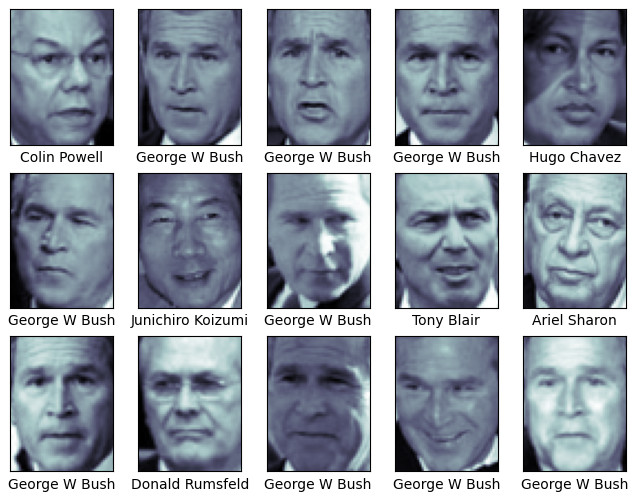

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 5, figsize=(8, 6))
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

Each image contains 62 $\times$ 47 (just under 3000) pixels. We will reduce the dimensionality of the data using Principal Component Analysis or `PCA` (we will cover PCA in detail during the next lecture), turning the 3000 dimension input vectors into 150 dimensions by choosing the 150 most fundamental pixels (or combinations thereof).

To streamline the process, we will package the `PCA` and `SVC` models into a single pipeline:


In [4]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

pca = PCA(n_components=150, whiten=True,
        svd_solver='randomized', random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

We split the data into training and test sets:

In [5]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target,
                                                random_state=42)

Finally, we train our model pipeline:

In [6]:
model.fit(Xtrain, ytrain)

,steps,"[('pca', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_components,150
,copy,True
,whiten,True
,svd_solver,'randomized'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10


Now, we predict the trained model on the test set:

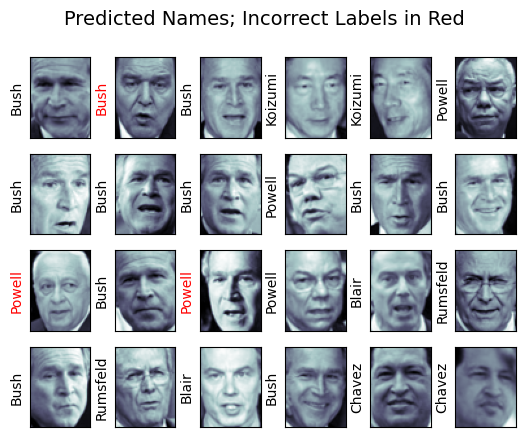

In [7]:
yfit = model.predict(Xtest)

fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);

### Improving the model with model selection

__Model selection__

TODO: Run a cross-validation experiment to select the best hyperparameters `C` and `gamma` for the `SVC` model.
Use `GridSearchCV` and give it the `param_grid` dictionary below.
We have to use a special syntax this time because we now have a `pipeline` object instead of a plain `SVC` model.

Find the best model using `grid.best_estimator_` and use it to predict the labels in the test set.

In [8]:
# Perform grid search
from sklearn.model_selection import GridSearchCV

# Define the parameters to be searched and the ranges.
param_grid = {'svc__C': [1, 5, 10, 50],
                       'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}

In [9]:
## 2. Find best model, predict Xtest

best_model = GridSearchCV(model, param_grid)

best_model

,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'svc__C': [1, 5, ...], 'svc__gamma': [0.0001, 0.0005, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,150


Plotting the newly predicted images. Are they better than before model selection?


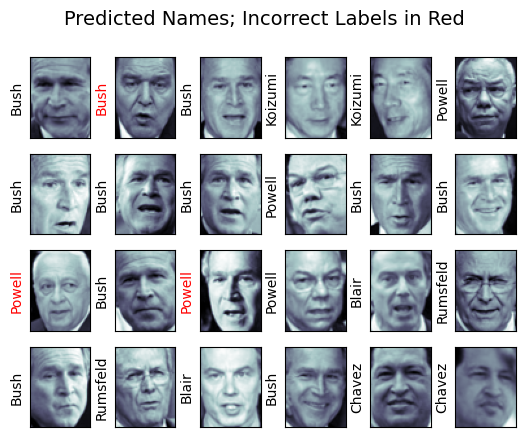

In [10]:
yfit = model.predict(Xtest)

fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);